In [2]:
%store -r combined_df

In [3]:
import hvplot.pandas
from scipy.stats import pearsonr
from scipy.stats import shapiro
from sklearn.linear_model import LinearRegression

In [4]:
combined_df

,inner_temp,outer_temp,data_count,diff_temps,inner_NDVI,outer_NDVI,diff_ndvis
year,,,,,,,
2001.0,303.969465,302.605033,10.0,1.364432,0.575758,0.563070,0.012688
2002.0,315.397217,309.096171,17.0,6.301047,0.287545,0.476006,-0.188461
2003.0,313.969845,308.514145,17.0,5.455700,0.317190,0.519118,-0.201928
2004.0,303.818255,300.497750,19.0,3.320505,0.371030,0.523545,-0.152516
2005.0,311.091337,306.569503,15.0,4.521835,0.373056,0.547559,-0.174502
2006.0,305.625640,302.594453,17.0,3.031187,0.353584,0.507795,-0.154212
2007.0,306.005837,302.326041,18.0,3.679796,0.408413,0.541945,-0.133532
2008.0,311.256641,305.865070,19.0,5.391571,0.337373,0.513005,-0.175633
2009.0,304.954379,301.513397,16.0,3.440981,0.413318,0.556825,-0.143507


In [10]:
dropped_first_year = combined_df.drop(2001)
dropped_first_year

,inner_temp,outer_temp,data_count,diff_temps,inner_NDVI,outer_NDVI,diff_ndvis
year,,,,,,,
2002.0,315.397217,309.096171,17.0,6.301047,0.287545,0.476006,-0.188461
2003.0,313.969845,308.514145,17.0,5.455700,0.317190,0.519118,-0.201928
2004.0,303.818255,300.497750,19.0,3.320505,0.371030,0.523545,-0.152516
2005.0,311.091337,306.569503,15.0,4.521835,0.373056,0.547559,-0.174502
2006.0,305.625640,302.594453,17.0,3.031187,0.353584,0.507795,-0.154212
2007.0,306.005837,302.326041,18.0,3.679796,0.408413,0.541945,-0.133532
2008.0,311.256641,305.865070,19.0,5.391571,0.337373,0.513005,-0.175633
2009.0,304.954379,301.513397,16.0,3.440981,0.413318,0.556825,-0.143507
2010.0,309.427356,304.574391,11.0,4.852965,0.388620,0.550164,-0.161543


In [11]:
# Normality tests
print('NDVIs: ',shapiro(dropped_first_year.diff_ndvis)) # Not normal
print('Temps:' , shapiro(dropped_first_year.diff_temps))

NDVIs:  ShapiroResult(statistic=np.float64(0.9560912388481523), pvalue=np.float64(0.36502091118338764))
Temps: ShapiroResult(statistic=np.float64(0.9792818225484937), pvalue=np.float64(0.8822685474009349))


<Axes: xlabel='diff_ndvis', ylabel='diff_temps'>

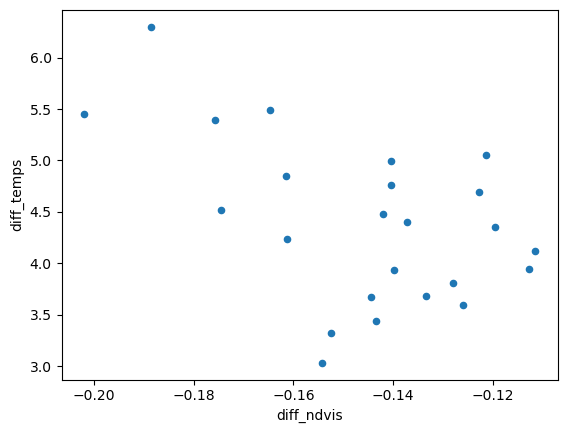

In [12]:
dropped_first_year.plot.scatter(x="diff_ndvis", y="diff_temps")

In [13]:
pearsonr(dropped_first_year.diff_ndvis, dropped_first_year.diff_temps) # Statistically significant, but not fully to be trusted

PearsonRResult(statistic=np.float64(-0.5055135895031564), pvalue=np.float64(0.011738025209481563))

In [13]:
print(len(combined_df))

25
